In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

randomstate = 23

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/febbisena/DataMining/refs/heads/main/Raisin_Dataset.csv')
df


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nDistribusi kelas:")
print(y.value_counts())


Distribusi kelas:
Class
Kecimen    450
Besni      450
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=randomstate
)

print("Data train :", len(X_train))
print("Data test  :", len(X_test))

Data train : 675
Data test  : 225


In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=randomstate
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=23)

In [ ]:
y_pred = model.predict(X_test)

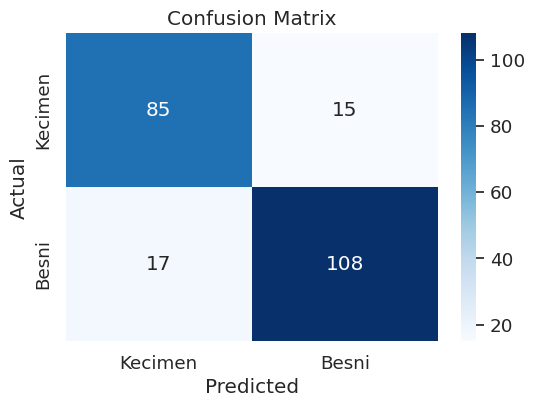

In [ ]:
class_names = y.unique()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.set(font_scale=1.2)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
class_report = classification_report(
    y_test, y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

     Kecimen     0.8333    0.8500    0.8416       100
       Besni     0.8780    0.8640    0.8710       125

    accuracy                         0.8578       225
   macro avg     0.8557    0.8570    0.8563       225
weighted avg     0.8582    0.8578    0.8579       225



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")

Accuracy Score: 85.78%


In [ ]:
test_df = pd.DataFrame(X_test, columns=X.columns)

test_df['Actual Class'] = y_test.values
test_df['Predicted Class'] = y_pred

print(test_df.head())

      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
774  76624       473.965993       207.736989      0.898831       80356   
737  48007       302.611047       209.116084      0.722817       50679   
753  79057       436.390047       236.895393      0.839828       82642   
890  85646       469.774755       238.539384      0.861490       92673   
428  48093       329.935742       187.041722      0.823784       49367   

       Extent  Perimeter Actual Class Predicted Class  
774  0.661008   1205.819        Besni           Besni  
737  0.677051    889.743        Besni         Kecimen  
753  0.654597   1148.146        Besni           Besni  
890  0.681044   1226.892        Besni           Besni  
428  0.745108    858.386      Kecimen           Besni  


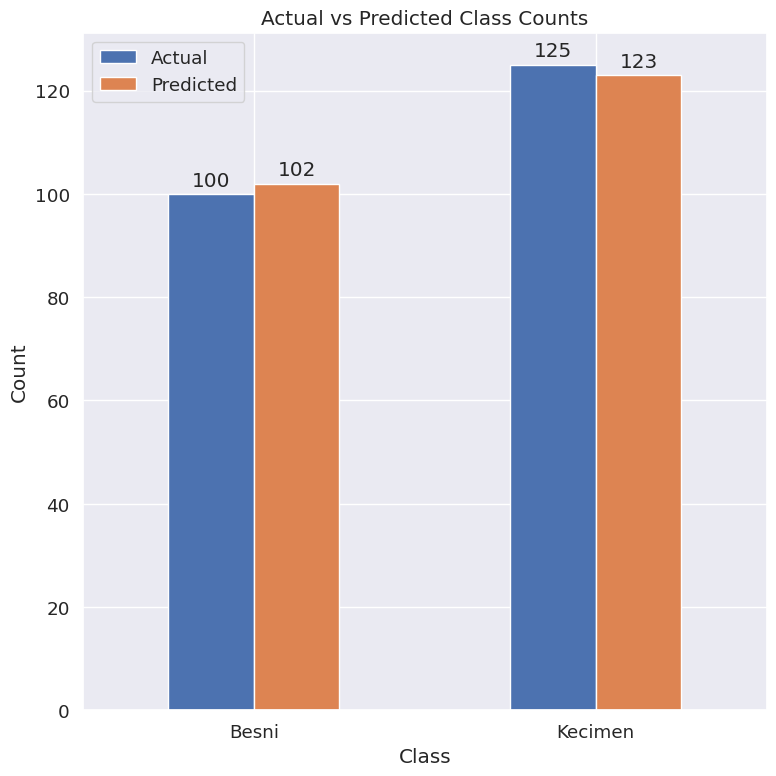

In [ ]:
comparison_df = test_df.groupby('Actual Class').size().to_frame('Actual')
comparison_df['Predicted'] = test_df.groupby('Predicted Class').size()

comparison_df.fillna(0, inplace=True)
comparison_df = comparison_df.astype(int)

ax = comparison_df.plot(kind='bar', figsize=(8, 8))

ax.bar_label(ax.containers[0], fmt='%d', padding=3)
ax.bar_label(ax.containers[1], fmt='%d', padding=3)

plt.title('Actual vs Predicted Class Counts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
test_df.to_excel('C45_Data_Test_&_Prediction.xlsx', index=False)

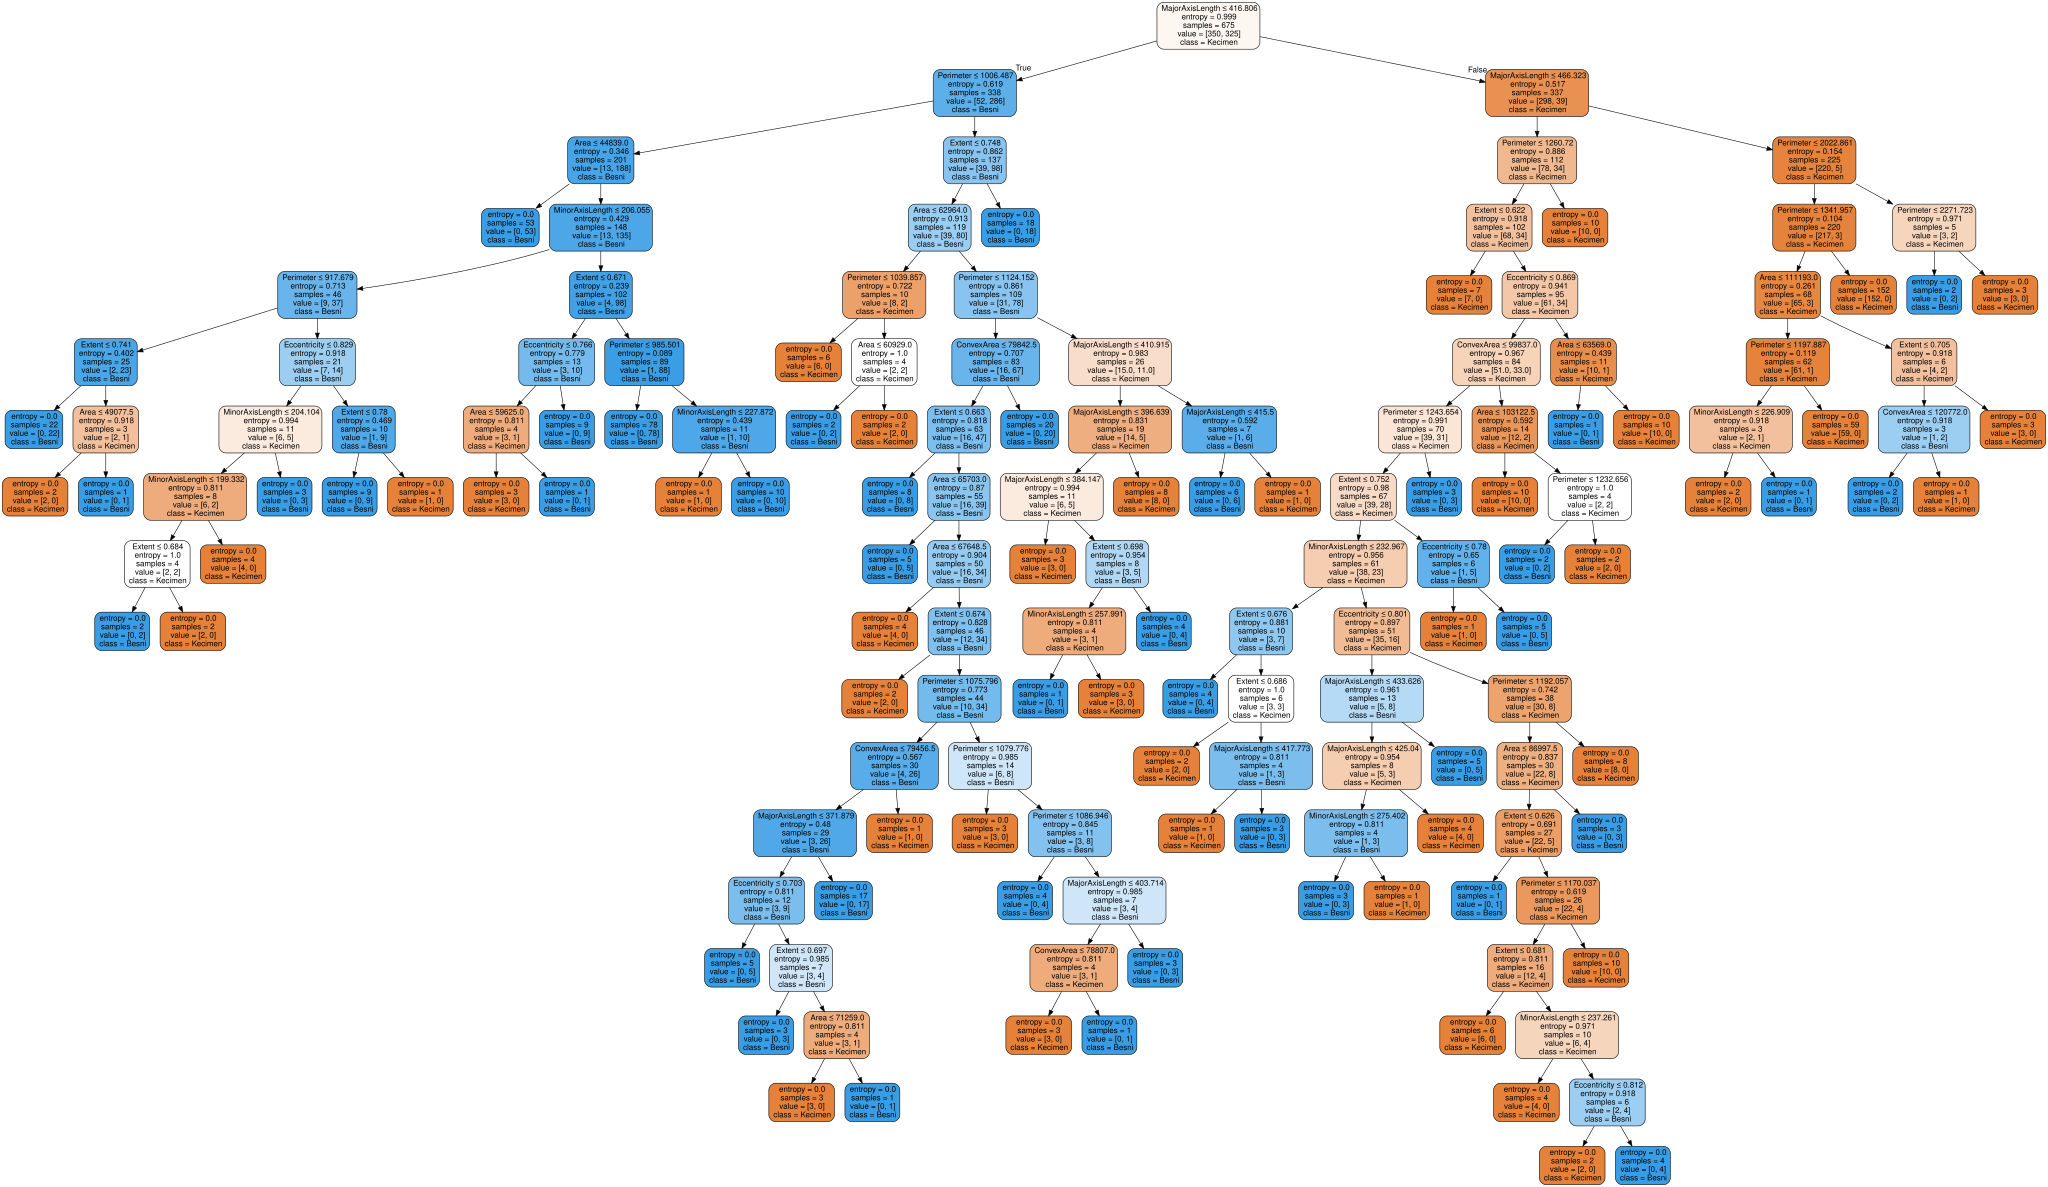

In [ ]:
feature_names = X.columns.tolist()
class_names = y.unique().tolist()

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render(filename='decision_tree', format='png', cleanup=True)

graph